# IEEE Fraud Dataset

## Reading and Cleaning of Data

In [49]:
## Importing necessary libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

import joblib
import json

In [2]:
## The transaction dataset is too large to be imported with my RAM configuration hence I first look at random 10,000 rows
## and try to remove unnecessary columns:

no_rows = 10000

df1 = pd.read_csv("ieee-fraud-detection/train_transaction.csv",nrows=no_rows,skiprows=lambda x: x %np.random.randint(1,10))

## the lambda function here takes a row number and randomly checks if it is divisble by a number between 1 and 10.

In [3]:
## simple peak at the data.

df1.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987005,0,86510,49.00,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987013,0,86585,40.00,W,12866,303.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987017,0,86668,100.00,H,11492,111.0,150.0,mastercard,219.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987019,0,86730,186.00,W,7005,111.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987023,0,86808,107.95,W,2392,360.0,150.0,mastercard,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## check if the column is mostly missing data and making a list of good columns

column_name = []
for columns in df1.columns:
    no_missing_val = df1[columns].isna().sum()
#     print(f"{coloumns}: {df1[coloumns].isna().sum()}")
    if no_missing_val < 0.70*no_rows:
        column_name.append(columns)

In [5]:
## Reading the entire data with good columns only

df1 = pd.read_csv("ieee-fraud-detection/train_transaction.csv",usecols=column_name)

In [6]:
## The V-columns in the dataset are known to have high correlation among themselves,
## checking the corr-matrix and dropping highly correlated columns
v_cols = [c for c in df1.columns if c.startswith('V')] # getting all the V-columns
v_df1 = df1[v_cols] 
corr_matrix = v_df1.corr().abs() # generating the corr-matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)] # making a list of all columns to be dropped
df1 = df1.drop(columns=to_drop) # dropping the columns

In [7]:
## drops highlycorrelated columns of the C and D type

CD_cols = [c for c in df1.columns if c.startswith('C') or c.startswith('D')] # getting all the C and D-columns
CD_df1 = df1[CD_cols]
corr_matrix = CD_df1.corr().abs() # generating the corr-matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)] # making a list of all columns to be dropped
df1 = df1.drop(columns=to_drop)

In [8]:
## Peak at final transaction dataset
df1.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V309,V310,V311,V312,V313,V314,V315,V319,V320,V321
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,0.0,354.0,0.0,135.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
## Reading in the identity dataset

df2 = pd.read_csv("ieee-fraud-detection/train_identity.csv")

In [10]:
## Checking nan/null values in the identity table

df2.isna().sum()/len(df2)

TransactionID    0.000000
id_01            0.000000
id_02            0.023303
id_03            0.540161
id_04            0.540161
id_05            0.051084
id_06            0.051084
id_07            0.964259
id_08            0.964259
id_09            0.480521
id_10            0.480521
id_11            0.022568
id_12            0.000000
id_13            0.117262
id_14            0.445037
id_15            0.022519
id_16            0.103257
id_17            0.033723
id_18            0.687221
id_19            0.034077
id_20            0.034472
id_21            0.964231
id_22            0.964162
id_23            0.964162
id_24            0.967088
id_25            0.964419
id_26            0.964204
id_27            0.964162
id_28            0.022568
id_29            0.022568
id_30            0.462224
id_31            0.027393
id_32            0.462079
id_33            0.491871
id_34            0.460560
id_35            0.022519
id_36            0.022519
id_37            0.022519
id_38       

In [11]:
## dropping columns with mostly missing values

to_drop2 = [column for column in df2.columns if df2[column].isna().sum()/len(df2) > 0.75]
df2 = df2.drop(columns=to_drop2)

In [12]:
## Merging the two dataset to form the main table

df = df1.merge(df2, on='TransactionID', how='left')

In [13]:
# peak at the complete dataset

df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [14]:
## Checking nan/null values in the complete table

df.isna().sum()/len(df)

TransactionID     0.000000
isFraud           0.000000
TransactionDT     0.000000
TransactionAmt    0.000000
ProductCD         0.000000
                    ...   
id_36             0.761261
id_37             0.761261
id_38             0.761261
DeviceType        0.761557
DeviceInfo        0.799055
Length: 190, dtype: float64

In [15]:
## we will not need Transaction ID anymore so we can drop it 
df = df.drop(columns=["TransactionID"])

In [16]:
## Further, numerical columns with mostly missing entry can be dropped

missing_num_col = [column for column in df.columns if df[column].isna().sum()/len(df) > 0.70 and df[column].dtype != "object"]
df[missing_num_col].info()
df = df.drop(columns=missing_num_col)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 16 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id_01   144233 non-null  float64
 1   id_02   140872 non-null  float64
 2   id_03   66324 non-null   float64
 3   id_04   66324 non-null   float64
 4   id_05   136865 non-null  float64
 5   id_06   136865 non-null  float64
 6   id_09   74926 non-null   float64
 7   id_10   74926 non-null   float64
 8   id_11   140978 non-null  float64
 9   id_13   127320 non-null  float64
 10  id_14   80044 non-null   float64
 11  id_17   139369 non-null  float64
 12  id_18   45113 non-null   float64
 13  id_19   139318 non-null  float64
 14  id_20   139261 non-null  float64
 15  id_32   77586 non-null   float64
dtypes: float64(16)
memory usage: 72.1 MB


In [17]:
## Now that one can seperate out numerical and categorical columns

numerical_col = [column for column in df.columns if df[column].dtype != "object"]
categorical_col = [column for column in df.columns if df[column].dtype == "object"]

In [18]:
## The missing value in categorical columns can be filled with missing 
## and the type can be changed to category instead of object (as missing could be a sign of fraudulent transaction)

for column in categorical_col:
    df[column] = df[column].fillna('missing')
    df[column] = df[column].astype('category')

In [19]:
df["DeviceInfo"].unique()

['missing', 'SAMSUNG SM-G892A Build/NRD90M', 'iOS Device', 'Windows', 'MacOS', ..., 'G630-U251', 'LG-K212', 'LDN-LX3 Build/HUAWEILDN-LX3', 'Z955A', 'LG-E975']
Length: 1787
Categories (1787, object): ['0PAJ5', '0PJA2', '0PM92', '1016S', ..., 'verykools5034', 'verykools5035', 'vivo', 'xs-Z47b7VqTMxs']

In [20]:
df["DeviceInfo"].value_counts()

DeviceInfo
missing                  471874
Windows                   47722
iOS Device                19782
MacOS                     12573
Trident/7.0                7440
                          ...  
DASH                          1
D6603                         1
SM-J250M Build/NMF26X         1
verykoolS5524                 1
verykoolS5019                 1
Name: count, Length: 1787, dtype: int64

In [21]:
## Moreover Deviceinfo has too many unique values, need to clean it a bit

def clean_device_info(x):
    x = str(x).lower()
    if 'windows' in x: return 'windows'
    if 'ios' in x or 'iphone' in x: return 'ios'
    if 'mac' in x: return 'mac'
    if 'android' in x or 'samsung' in x or 'sm-' in x: return 'android'
    if 'rv:' in x: return 'browser_engine'
    if 'nan' in x or 'missing' in x: return 'missing'
    return 'other'

df['DeviceInfo_Grouped'] = df['DeviceInfo'].apply(clean_device_info)

In [22]:
df[numerical_col] = df[numerical_col].fillna(df[numerical_col].median())

In [24]:
## Final peak at data before full-fledged EDA

df.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,DeviceInfo_Grouped
0,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
1,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
2,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
3,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
4,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,samsung browser 6.2,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,android


In [24]:
## Convert the TransactionDT, which is in seconds to hours and day of the week, this will help us identify pattern

df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7

In [25]:
df = df.drop(columns=["DeviceInfo"])

In [26]:
df.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo_Grouped,hour,day_of_week
0,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
1,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
2,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
3,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
4,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,2220x1080,match_status:2,T,F,T,T,mobile,android,0,1


In [31]:
## saving cleaned data to data folder
# df.to_csv("ieee-fraud-detection/cleaned_dataset.csv")

## EDA

In [32]:
df.head()

,isFraud,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo_Grouped,hour,day_of_week
0,0,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
1,0,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
2,0,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
3,0,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,...,missing,missing,missing,missing,missing,missing,missing,missing,0,1
4,0,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,...,2220x1080,match_status:2,T,F,T,T,mobile,android,0,1


isFraud
0    96.500999
1     3.499001
Name: count, dtype: float64

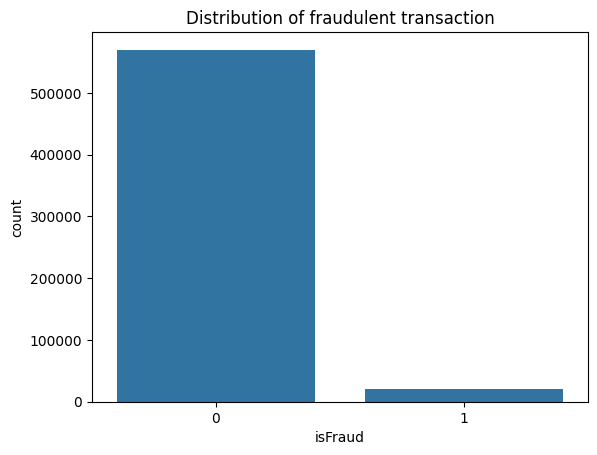

In [33]:
## visulaizing the class imbalance in Fraud transactions

sn.countplot(data=df, x = "isFraud")
plt.title("Distribution of fraudulent transaction")
df["isFraud"].value_counts()/df["isFraud"].count()*100

Here one can clearly see we have a heavy class imbalance in the target function, however the VAE only learns what a normal transaction looks like, so here this works in our favour.

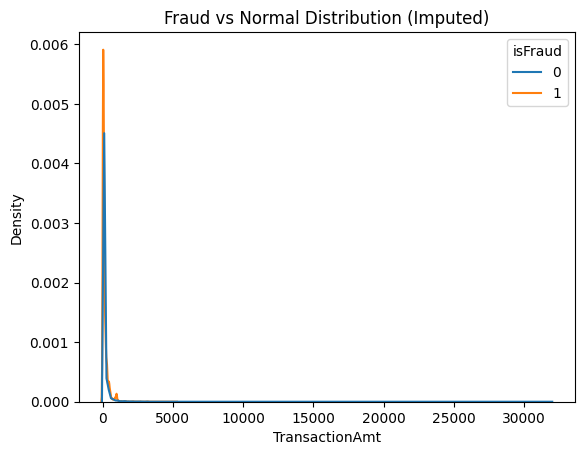

In [34]:
## Next we look at the distribution of transaction amount and its relation to Fraud

sn.kdeplot(data=df, x='TransactionAmt', hue='isFraud', common_norm=False)
plt.title("Fraud vs Normal Distribution (Imputed)")
plt.show()

Without log scaling the above data nothing concrete can be told about the role transaction amount plays in fraud-like transactions 

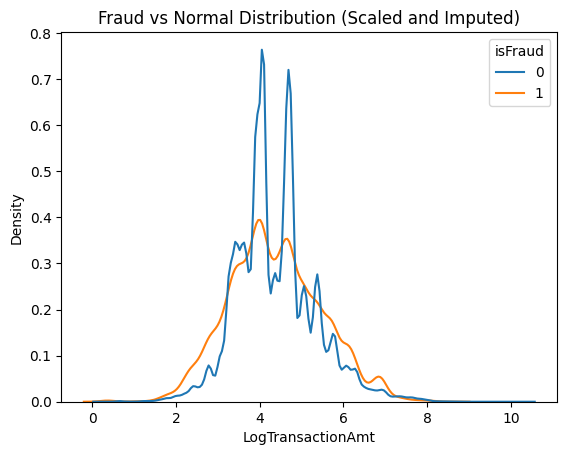

In [28]:
## clearly this is not scaled correctly, scalling logarithmically

df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])
sn.kdeplot(data=df, x='LogTransactionAmt', hue='isFraud', common_norm=False)
plt.title("Fraud vs Normal Distribution (Scaled and Imputed)")
plt.show()

With the log-scaled transaction amount, one can clearly see that fraudlike transactions happen for small amounts rather that large amounts. Keeping this column log scaled gives better idea of what normal and abnormal looks like.

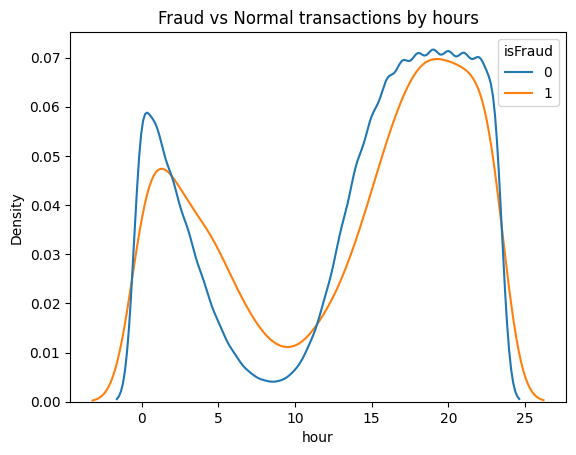

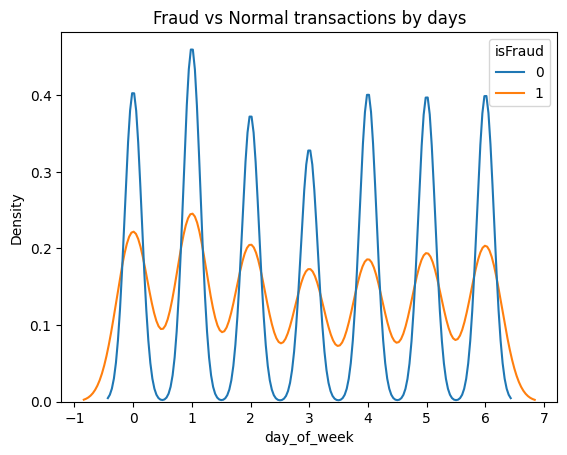

In [37]:
## Plot the fraudulant transaction by different hours and days of the week to see if there are releavnt patterns

sn.kdeplot(data=df, x='hour', hue='isFraud', common_norm=False)
plt.title("Fraud vs Normal transactions by hours")
plt.show()

sn.kdeplot(data=df, x='day_of_week', hue='isFraud', common_norm=False)
plt.title("Fraud vs Normal transactions by days")
plt.show()

It seems that fraud transactions happen more often during night and early morning time. They dont seem to have any definite pattern with respect to days of the week. however, it seems like there is a slight increase during the start of the week. 

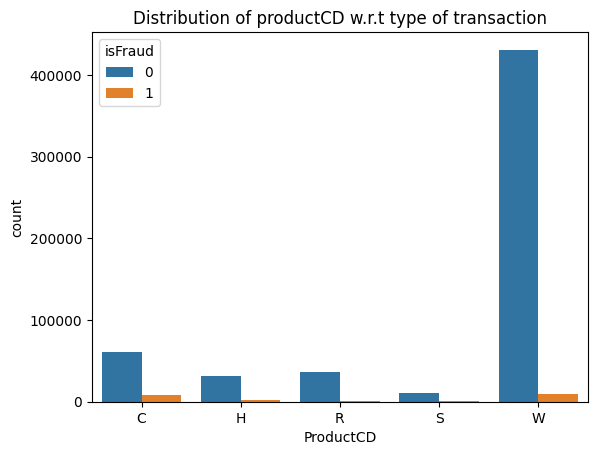

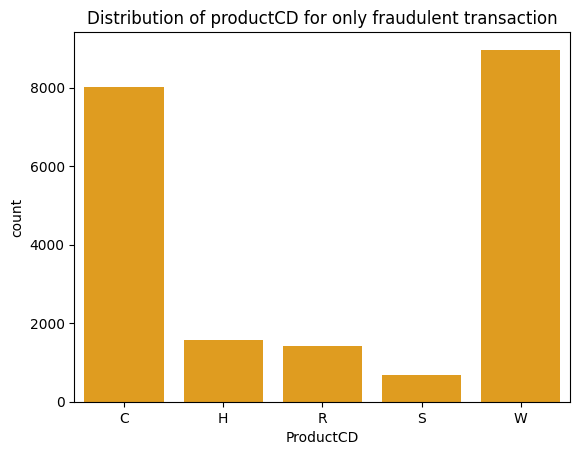

In [38]:
## Visulaizing Fraud dependence on productCD

sn.countplot(data=df, x = "ProductCD", hue = "isFraud")
plt.title("Distribution of productCD w.r.t type of transaction")
plt.show()

sn.countplot(data=df[df["isFraud"]==1], x = "ProductCD", color = "orange")
plt.title("Distribution of productCD for only fraudulent transaction")
plt.show()

Here it is abundantly clear that product with code C and W are most likely to be targeted by fraudsters. Moreover, most volumuos product is type W.

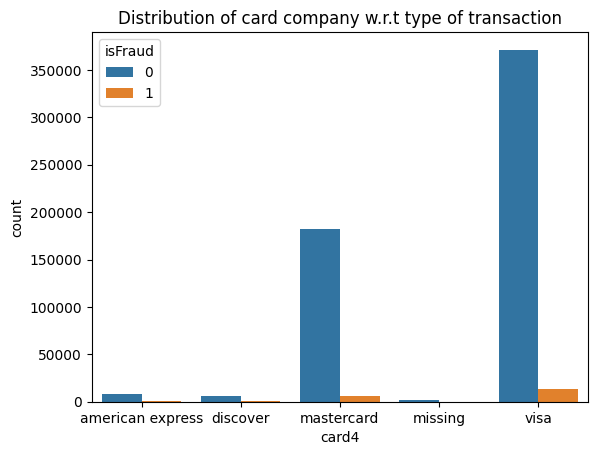

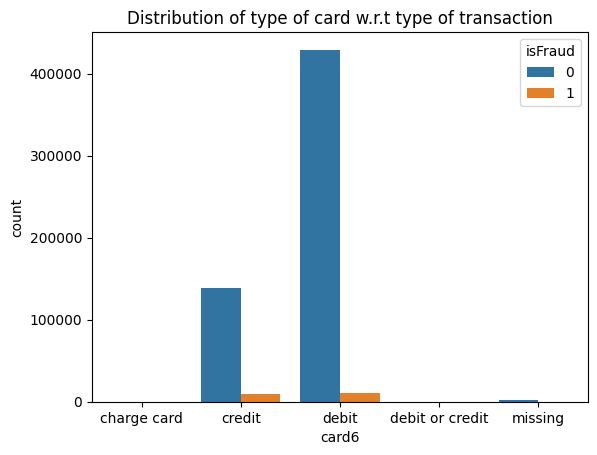

In [39]:
## Visulaizing Fraud dependence on Card4 (card company) and card6 (type of card)

sn.countplot(data=df, x = "card4", hue = "isFraud")
plt.title("Distribution of card company w.r.t type of transaction")
plt.show()

sn.countplot(data=df, x = "card6", hue = "isFraud")
plt.title("Distribution of type of card w.r.t type of transaction")
plt.show()

Most fraudlike transaction happen via debit cards and Visa cards.

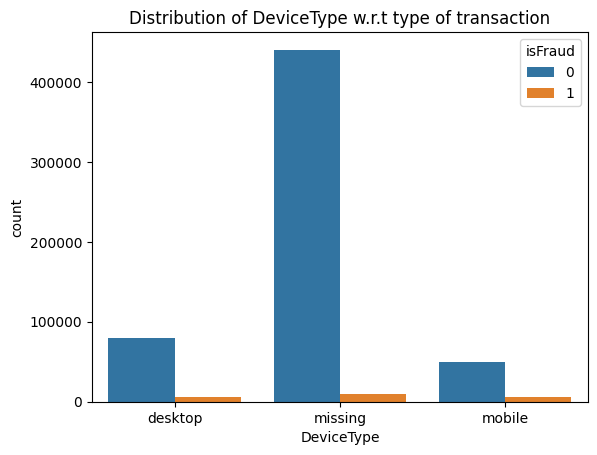

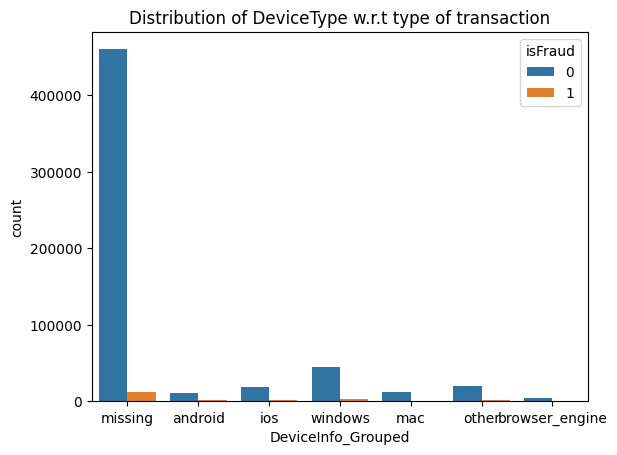

In [40]:
## Visulaizing Fraud dependence on Devicetype

sn.countplot(data=df, x = "DeviceType", hue = "isFraud")
plt.title("Distribution of DeviceType w.r.t type of transaction")
plt.show()

sn.countplot(data=df, x = "DeviceInfo_Grouped", hue = "isFraud")
plt.title("Distribution of DeviceType w.r.t type of transaction")
plt.show()

Here missing device info seems like a good indication of fraudlike transactions.

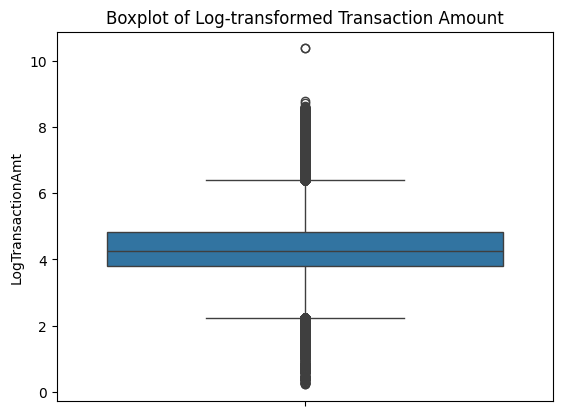

In [50]:
## Next we check for outliers in high variance columns

sn.boxplot(y = df["LogTransactionAmt"])
plt.title("Boxplot of Log-transformed Transaction Amount")
plt.show()

In [29]:
outlier_idx = df['LogTransactionAmt'].idxmax()
df = df.drop(index=outlier_idx)

In [30]:
## we can also drop the original transactionAmt column now

df = df.drop(columns="TransactionAmt")

Other columns do not show any extreme outliers that can be clipped, rest of the outliers are important for VAE to understand what normal is.

In [32]:
df.to_csv("data/cleaned_dataset.csv", index = False)

## Pre-processing of data

In [33]:
df = pd.read_csv("data/cleaned_dataset.csv")

In [34]:
## shuffle is set to false to not mix the chronological data

train_df , val_df = train_test_split(df, test_size= 0.2, shuffle = False)

In [35]:
## the TransactionDT column can now be dropped

train_df = train_df.drop(columns = "TransactionDT")
val_df = val_df.drop(columns = "TransactionDT")

In [36]:
#3 For VAE, only the normal transaction is needed

train_df = train_df[train_df["isFraud"] == 0]
train_df = train_df.drop(columns="isFraud")

In [68]:
## First a small sample is used to train the VAE, it is easier and faster to debug when training with a smaller set
## and then doing a full training

train_df = train_df[0:10000]
val_df = val_df[0:2000]
X_val_df = val_df.drop(columns="isFraud")
Y_val_df = val_df["isFraud"]

In [71]:
## Seperate out numerical and categorical columns for scaling and encoding

num_col = train_df.select_dtypes(include = ["number"]).columns.tolist()
cat_col = train_df.select_dtypes(include=["object"]).columns.tolist()

In [72]:
## Checking how many unique value each categorical column has

train_df[cat_col].nunique()

ProductCD              5
card4                  5
card6                  3
P_emaildomain         51
M1                     2
M2                     3
M3                     3
M4                     4
M5                     3
M6                     3
id_12                  3
id_15                  4
id_16                  3
id_28                  3
id_29                  3
id_30                 54
id_31                 53
id_33                 53
id_34                  4
id_35                  3
id_36                  3
id_37                  3
id_38                  3
DeviceType             3
DeviceInfo_Grouped     7
dtype: int64

There are some columns with 50ish entries, even though these contain essentially different android or browser versions and could be cleaned to lower the cardinality, all of these are kept to see if scammers prefer certain versions. Onehotencoding is still okay for such number of categories.

In [73]:
## setting up the preprocessor

preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_col),
                                               ("cat", OneHotEncoder(handle_unknown="ignore"),cat_col)])

In [74]:
## Fitting the columntransformer to the training set

preprocessor.fit(train_df)
joblib.dump(preprocessor,"model/transform_rule.pkl")

['model/transform_rule.pkl']

In [82]:
## Converting data type to float32 and transforming the data as well

X_train_transformed = preprocessor.transform(train_df).astype("float32")
X_val_transformed = preprocessor.transform(X_val_df).astype("float32")

In [83]:
## save the transformed data as a matrix

np.save("data/processed/trainset.npy" ,X_train_transformed)
np.save("data/processed/testset.npy" ,X_val_transformed)

In [84]:
## Getting the feature name as well

feature_list = preprocessor.get_feature_names_out()

In [85]:
## preparing feature name to be saved

feature_list = feature_list.tolist()

feature_dic = {
    "Model_version" : 1.0,
    "No. of rows" : len(feature_list),
    "feature_name" : feature_list
              }

In [86]:
## save feature name to a json file

with open("metadata/feature_name.json", "w") as f:
    json.dump(feature_dic,f)